In [70]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,log_loss,roc_curve,auc)

In [71]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [72]:
df.shape

(284807, 31)

In [73]:
def outliers(df,columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

In [74]:
df = outliers(df, ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 
                              'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 
                              'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 
                              'V26', 'V27', 'V28'])


In [75]:
df.shape

(120550, 31)

In [76]:
df[['Time', 'Amount']] = StandardScaler().fit_transform(df[['Time', 'Amount']])


In [77]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-2.040182,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.635478,0
1,-2.040182,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.659751,0
5,-2.040139,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,-0.644442,0
6,-2.040096,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,-0.623822,0
9,-2.039989,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,-0.644286,0


### Descriptive Analytics 


In [78]:
fraud_count = df[df['Class'] == 1].shape[0]
non_fraud_count = df[df['Class'] == 0].shape[0]

print(f"Total fraud transactions: {fraud_count}")
print(f"Total non-fraud transactions: {non_fraud_count}")



Total fraud transactions: 13
Total non-fraud transactions: 120537


#### As seen there are negligible amount of fraud transaction

In [79]:
correlations = df.corr()['Class'].sort_values()

correlations


V14      -0.013340
V23      -0.006417
V19      -0.006164
Time     -0.006095
V10      -0.005970
V1       -0.004246
V12      -0.004068
V9       -0.003944
V26      -0.003892
Amount   -0.002556
V13      -0.002460
V24      -0.001119
V8       -0.000513
V27      -0.000305
V20      -0.000079
V22       0.000083
V21       0.000189
V6        0.000332
V15       0.002218
V3        0.002226
V28       0.002276
V25       0.003348
V11       0.003462
V16       0.004515
V18       0.004778
V7        0.005769
V5        0.006494
V4        0.006547
V2        0.008458
V17       0.010869
Class     1.000000
Name: Class, dtype: float64

#### According to the output the feature V17 have the highest corelation with the target variable Class

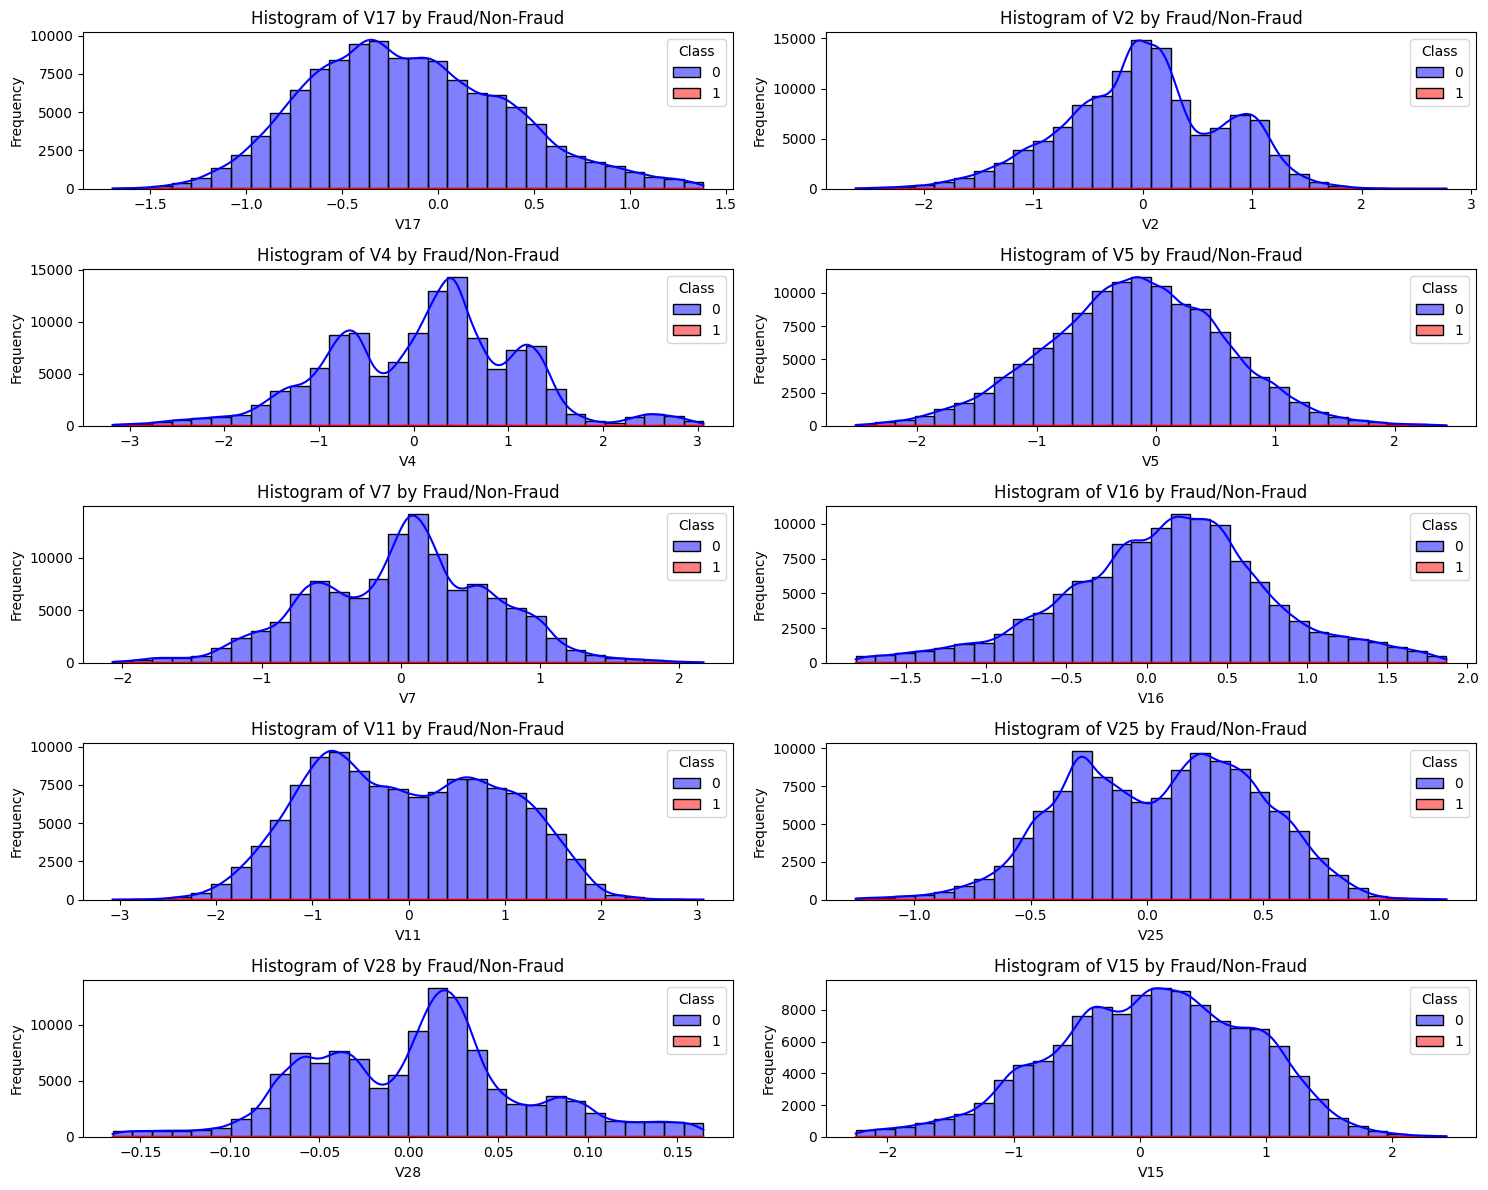

In [80]:
top_features = ['V17', 'V2', 'V4', 'V5', 'V7', 'V16', 'V11', 'V25', 'V28', 'V15']
plt.figure(figsize=(15, 12))

for i, feature in enumerate(top_features, 1):
    plt.subplot(5, 2, i)
    sns.histplot(data=df, x=feature, hue='Class', kde=True, bins=30, palette={0: 'blue', 1: 'red'})
    plt.title(f'Histogram of {feature} by Fraud/Non-Fraud')
    plt.xlabel(f'{feature}')
    plt.ylabel('Frequency')

# Adjust layout
plt.tight_layout()
plt.show()


In [81]:
X = df.drop(columns=['Class'])  
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [82]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
cross_val_scores = cross_val_score(logreg, X_train, y_train, cv=5, scoring='accuracy')

In [83]:
cross_val_scores

array([0.99989631, 0.99989631, 0.99989631, 0.99984446, 0.99984446])

In [84]:
logreg.fit(X_train, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [85]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logreg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)
coefficients

,Feature,Coefficient
6,V6,1.038760
4,V4,0.499948
17,V17,0.454676
24,V24,0.348701
20,V20,0.306684
11,V11,0.249703
25,V25,0.215008
15,V15,0.210344
18,V18,0.210041
13,V13,0.189505


In [86]:
most_influential = coefficients.iloc[0]
most_influential

Feature             V6
Coefficient    1.03876
Name: 6, dtype: object

In [87]:
y_pred = logreg.predict(X_test)
y_pred_prob = logreg.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

c:\Users\Jimit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [90]:
print("Accuracy =", accuracy, "Precision =", precision, "Recall =", recall, "F1-Score =", f1)


Accuracy = 0.9999585234342596 Precision = 0.0 Recall = 0.0 F1-Score = 0.0


In [91]:
log_loss_manual = -np.mean(
    y_test * np.log(y_pred_prob) + (1 - y_test) * np.log(1 - y_pred_prob)
)
log_loss_manual

np.float64(0.0005300765783191391)

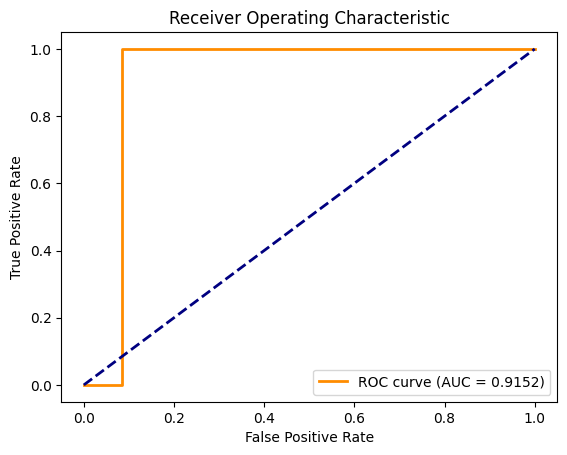

In [92]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [93]:
roc_auc

np.float64(0.9152183831764071)